# ResNet50

**Owner:** Sajalee
**Model:** ResNet50

This notebook covers: data loading, preprocessing, model architecture, training, and evaluation for the ResNet50 model, as part of the SE4050 group assignment.

Follows the group's **Finalized Experiment Configuration**:
- Input: 64×64×3 RGB, 43 classes
- Two-phase transfer learning (frozen backbone @ LR 1e-3 → fine-tune @ LR 1e-5)
- Batch size 32, max 30 epochs, early stopping (patience 5, monitor val_loss), checkpoint = lowest val_loss
- Adam optimizer, Sparse Categorical Cross-Entropy, seed 42
- Augmentation on training set only (rotation, shift, zoom, mild brightness — no flips, since flipping changes sign meaning)

## 1. Imports

In [1]:
import os
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.21.0
GPUs available: []


## 2. Reproducibility

In [2]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)

## 3. Experiment Configuration

Fixed values from `Finalized_Experiment_Configuration.md`, shared identically across all four models so results are directly comparable.

In [3]:
IMG_SIZE      = 64
NUM_CHANNELS  = 3
NUM_CLASSES   = 43
BATCH_SIZE    = 32

MAX_EPOCHS    = 30          # total budget across both phases
PHASE1_EPOCHS = 15          # frozen backbone
PHASE2_EPOCHS = MAX_EPOCHS - PHASE1_EPOCHS  # fine-tuning
PATIENCE      = 5           # early stopping patience, monitors val_loss

LR_PHASE1 = 1e-3            # train head only, backbone frozen
LR_PHASE2 = 1e-5            # fine-tune upper layers, protect pretrained features

MODEL_NAME = "resnet50"
RESULTS_DIR = os.path.join("..", "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

CKPT_PHASE1 = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_phase1_best.keras")
CKPT_PHASE2 = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_phase2_best.keras")
CKPT_FINAL  = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_final_best.keras")

## 4. Load Dataset

Uses the shared, pre-generated split (`data/processed/gtsrb_data.npz`) so every model in the group trains/validates/tests on identical data. Do not regenerate this split.

In [4]:
DATA_CANDIDATES = [
    os.path.join("..", "data", "processed", "gtsrb_data.npz"),
    os.path.join("data", "processed", "gtsrb_data.npz"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "gtsrb_data.npz not found. Ask the group leader for the shared, "
        "pre-generated split and place it under data/processed/."
    )

data = np.load(DATA_PATH)
X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val     = data["X_val"], data["y_val"]
X_test, y_test   = data["X_test"], data["y_test"]

print("Loaded from:", DATA_PATH)
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name}: X={X.shape}, y={y.shape}, dtype={X.dtype}")

assert X_train.shape[1:] == (IMG_SIZE, IMG_SIZE, NUM_CHANNELS), (
    f"Expected images of shape ({IMG_SIZE},{IMG_SIZE},{NUM_CHANNELS}), got {X_train.shape[1:]}"
)
assert len(np.unique(y_train)) <= NUM_CLASSES

Loaded from: ..\data\processed\gtsrb_data.npz
train: X=(33327, 64, 64, 3), y=(33327,), dtype=float32
val: X=(5882, 64, 64, 3), y=(5882,), dtype=float32
test: X=(12630, 64, 64, 3), y=(12630,), dtype=float32


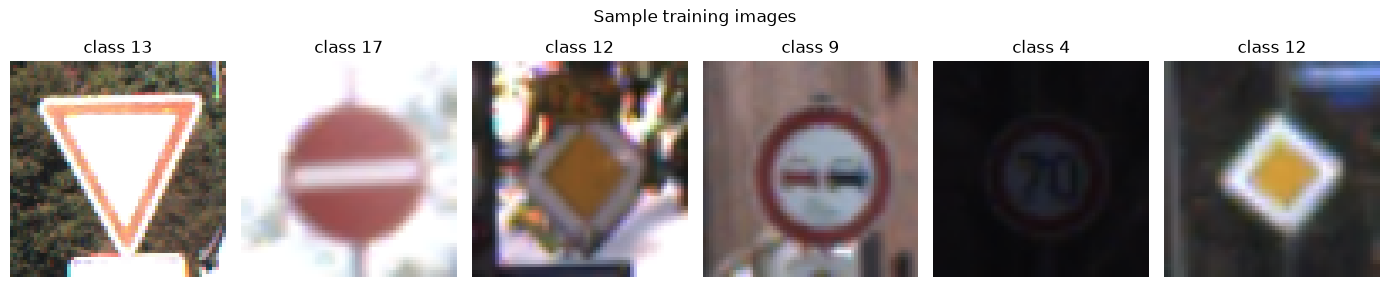

In [5]:
# Quick sanity check: a handful of training samples
fig, axes = plt.subplots(1, 6, figsize=(14, 3))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_train), size=6, replace=False)
for ax, idx in zip(axes, sample_idx):
    img = X_train[idx]
    img_disp = img.astype("uint8") if img.max() > 1.0 else img
    ax.imshow(img_disp)
    ax.set_title(f"class {y_train[idx]}")
    ax.axis("off")
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()

## 5. Data Pipeline & Augmentation

Augmentation is applied to the **training set only**. Horizontal/vertical flips are intentionally excluded — flipping a directional traffic sign (e.g. a turn arrow) changes its meaning.

`preprocess_input` for ResNet50 applies the ImageNet mean-subtraction the pretrained backbone expects, so it's applied to all three splits (after augmentation for the training split).

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(10 / 360),        # ±10 degrees
    layers.RandomTranslation(0.1, 0.1),     # ±10% width/height shift
    layers.RandomZoom(0.1),                 # ±10% zoom
    layers.RandomBrightness(0.1),           # mild brightness variation
], name="augmentation")

def make_dataset(X, y, training, batch_size=BATCH_SIZE):
    X = X.astype("float32")
    # The shared preprocessing pipeline already scaled pixels to [0, 1].
    # ResNet50's preprocess_input expects raw [0, 255] values (it does its
    # own ImageNet mean-subtraction calibrated for that range), so rescale back up.
    X = X * 255.0

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)
        ds = ds.batch(batch_size)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.batch(batch_size)
    ds = ds.map(lambda x, y: (preprocess_input(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val,   training=False)
test_ds  = make_dataset(X_test,  y_test,  training=False)

## 6. Model Architecture

ResNet50 pretrained on ImageNet as a frozen feature extractor, with a new classification head for 43 GTSRB classes. `include_top=False` drops ImageNet's original 1000-way head; `GlobalAveragePooling2D` collapses the final feature maps before the new Dense layers.

In [7]:
def build_model():
    base_model = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, NUM_CHANNELS),
    )
    base_model.trainable = False  # Phase 1: freeze the backbone entirely

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, NUM_CHANNELS))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="resnet50_gtsrb")
    return model, base_model

model, base_model = build_model()
model.summary()

Model: "resnet50_gtsrb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 2, 2, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 43)                  │          11,051 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,123,307 (92.02 MB)

 Trainable params: 535,595 (2.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 7. Training — Phase 1 (Frozen Backbone)

Only the new classification head is trained. Adam @ LR = 1e-3, Sparse Categorical Cross-Entropy (labels are integer class indices, not one-hot). Early stopping monitors `val_loss` with patience 5; the checkpoint keeps the epoch with the lowest `val_loss` in this phase.

In [8]:
print(X_train.min(), X_train.max())

0.0 1.0


In [9]:
for images, labels in train_ds.take(1):
    print(images.numpy().min(), images.numpy().max())

-123.68 151.061


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_phase1 = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
    ModelCheckpoint(CKPT_PHASE1, monitor="val_loss", save_best_only=True),
]

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks_phase1,
)

In [13]:
model = tf.keras.models.load_model(CKPT_PHASE1)
base_model = model.get_layer("resnet50")
print("Reloaded phase 1 best checkpoint.")

Reloaded phase 1 best checkpoint.


## 8. Training — Phase 2 (Fine-Tuning)

Unfreeze the backbone and continue training at a much lower LR (1e-5) so the pretrained ImageNet features aren't destroyed. `BatchNormalization` layers are kept frozen throughout fine-tuning — with a batch size of only 32, letting BN layers update would make their running statistics noisy and can destabilize training; this is standard practice when fine-tuning pretrained CNNs.

In [14]:
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False  # keep BN statistics stable during fine-tuning

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_phase2 = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True),
    ModelCheckpoint(CKPT_PHASE2, monitor="val_loss", save_best_only=True),
]

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_phase2,
)

Epoch 1/15
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 1963s 2s/step - accuracy: 0.8969 - loss: 0.2986 - val_accuracy: 0.9602 - val_loss: 0.1177
Epoch 2/15
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 1921s 2s/step - accuracy: 0.9454 - loss: 0.1624 - val_accuracy: 0.9708 - val_loss: 0.0791
Epoch 3/15
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 3312s 3s/step - accuracy: 0.9624 - loss: 0.1110 - val_accuracy: 0.9823 - val_loss: 0.0526
Epoch 4/15
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 2926s 3s/step - accuracy: 0.9741 - loss: 0.0784 - val_accuracy: 0.9876 - val_loss: 0.0432
Epoch 5/15
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 3900s 4s/step - accuracy: 0.9767 - loss: 0.0705 - val_accuracy: 0.9879 - val_loss: 0.0338
Epoch 6/15
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 4375s 4s/step - accuracy: 0.9831 - loss: 0.0514 - val_accuracy: 0.9640 - val_loss: 0.1409
Epoch 7/15
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 4054s 4s/step - accuracy: 0.9860 - loss: 0.0442 - val_accuracy: 0.9957 - val_loss: 0.0163
Epoch 8/15
1042/1042 ━━━━━━━━━━━━━━━━━━━━ 6225s 6s/step - accuracy: 0.9879 -

## 9. Select Final Checkpoint (Lowest Validation Loss Overall)

The spec requires keeping the checkpoint with the lowest validation loss. Since each phase's `ModelCheckpoint` only tracks "best within that phase," compare the two phase-best values here and carry the true winner forward as the final model.

In [15]:
best_val_loss_p1 = min(history_phase1.history["val_loss"])
best_val_loss_p2 = min(history_phase2.history["val_loss"])

print(f"Phase 1 best val_loss: {best_val_loss_p1:.4f}")
print(f"Phase 2 best val_loss: {best_val_loss_p2:.4f}")

best_ckpt = CKPT_PHASE1 if best_val_loss_p1 <= best_val_loss_p2 else CKPT_PHASE2
print("Selected checkpoint:", best_ckpt)

final_model = tf.keras.models.load_model(best_ckpt)
final_model.save(CKPT_FINAL)
print("Final model saved to:", CKPT_FINAL)

Phase 1 best val_loss: 0.2747
Phase 2 best val_loss: 0.0059
Selected checkpoint: ..\results\resnet50_phase2_best.keras
Final model saved to: ..\results\resnet50_final_best.keras


## 10. Evaluation

Evaluated only now, on the untouched official GTSRB test set. Reports the primary metric (accuracy) plus macro precision/recall/F1 and the confusion matrix, as required.

In [16]:
y_pred_probs = final_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

test_accuracy = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

print(f"Test Accuracy:      {test_accuracy:.4f}")
print(f"Macro Precision:    {macro_precision:.4f}")
print(f"Macro Recall:       {macro_recall:.4f}")
print(f"Macro F1:           {macro_f1:.4f}")
print()
print(classification_report(y_true, y_pred, zero_division=0))

395/395 ━━━━━━━━━━━━━━━━━━━━ 186s 460ms/step
Test Accuracy:      0.9502
Macro Precision:    0.9327
Macro Recall:       0.9131
Macro F1:           0.9198

              precision    recall  f1-score   support

           0       0.85      0.87      0.86        60
           1       0.91      0.97      0.94       720
           2       0.95      0.89      0.92       750
           3       0.95      0.92      0.93       450
           4       0.95      0.96      0.96       660
           5       0.90      0.96      0.93       630
           6       0.98      0.93      0.95       150
           7       0.94      1.00      0.97       450
           8       1.00      0.89      0.94       450
           9       0.99      1.00      0.99       480
          10       1.00      0.98      0.99       660
          11       0.98      0.99      0.98       420
          12       1.00      0.99      0.99       690
          13       0.99      0.99      0.99       720
          14       0.95      1.00  

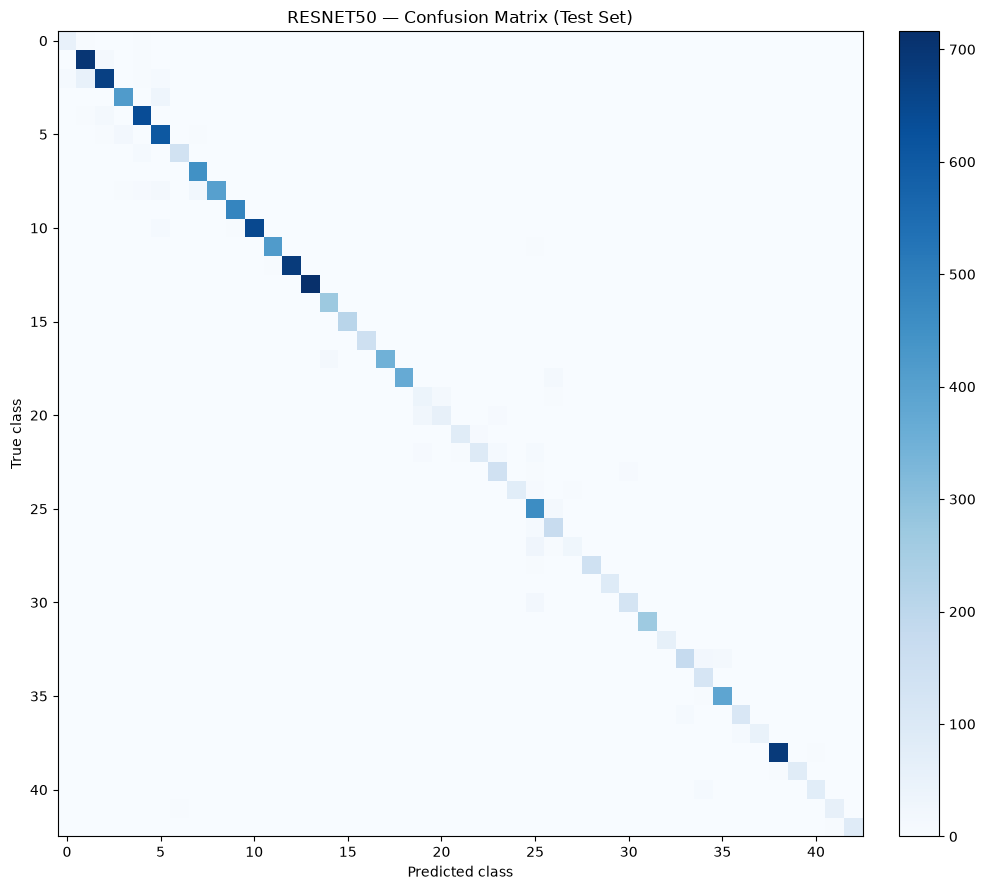

In [17]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_title(f"{MODEL_NAME.upper()} — Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"{MODEL_NAME}_confusion_matrix.png"), dpi=150)
plt.show()

## 11. Learning Curves

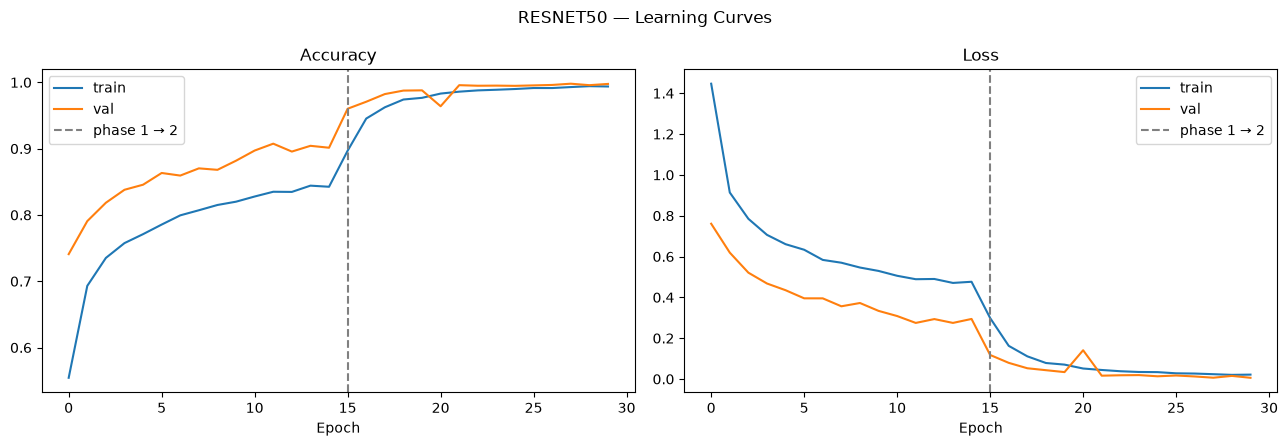

In [18]:
def combine_history(h1, h2, key):
    return h1.history[key] + h2.history[key]

acc = combine_history(history_phase1, history_phase2, "accuracy")
val_acc = combine_history(history_phase1, history_phase2, "val_accuracy")
loss = combine_history(history_phase1, history_phase2, "loss")
val_loss = combine_history(history_phase1, history_phase2, "val_loss")
phase_boundary = len(history_phase1.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(acc, label="train")
axes[0].plot(val_acc, label="val")
axes[0].axvline(phase_boundary, color="gray", linestyle="--", label="phase 1 → 2")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(loss, label="train")
axes[1].plot(val_loss, label="val")
axes[1].axvline(phase_boundary, color="gray", linestyle="--", label="phase 1 → 2")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle(f"{MODEL_NAME.upper()} — Learning Curves")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"{MODEL_NAME}_learning_curves.png"), dpi=150)
plt.show()

## 12. Save Results

In [19]:
metrics = {
    "model": MODEL_NAME,
    "seed": SEED,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "phase1_epochs_ran": len(history_phase1.history["loss"]),
    "phase2_epochs_ran": len(history_phase2.history["loss"]),
    "lr_phase1": LR_PHASE1,
    "lr_phase2": LR_PHASE2,
    "selected_checkpoint": best_ckpt,
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
}

metrics_path = os.path.join(RESULTS_DIR, f"{MODEL_NAME}_test_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics to:", metrics_path)
print(json.dumps(metrics, indent=2))

Saved metrics to: ..\results\resnet50_test_metrics.json
{
  "model": "resnet50",
  "seed": 42,
  "image_size": 64,
  "batch_size": 32,
  "phase1_epochs_ran": 15,
  "phase2_epochs_ran": 15,
  "lr_phase1": 0.001,
  "lr_phase2": 1e-05,
  "selected_checkpoint": "..\\results\\resnet50_phase2_best.keras",
  "test_accuracy": 0.9501979414093429,
  "macro_precision": 0.9326782172875417,
  "macro_recall": 0.9130983122502333,
  "macro_f1": 0.9197860296260224
}
